In [8]:
import numpy as np
import pydicom
import os

# DICOMファイルのパス
# folder_path = r"D:\Yamato\CT_Train_256_256_128_Zyukaku"
folder_path ="D:\Yamato\画像"

# すべてのDICOMファイルを読み込む
dicom_files = sorted([os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.dcm')])

# 3次元ボリュームにデータを結合するためのリストを作成
data_list = []

# すべてのDICOMファイルを処理
for file_path in dicom_files:
    # DICOMファイルの読み込み
    dicom_data = pydicom.dcmread(file_path)
    
    # DICOMデータから画像データを取得してリストに追加
    data_list.append(dicom_data.pixel_array.astype(float))

# 3次元に圧縮
compressed_data = np.stack(data_list, axis=-1)

# データの正規化
min_val = np.min(compressed_data)
max_val = np.max(compressed_data)
normalized_data = (compressed_data - min_val) / (max_val - min_val)
# normalized_data = compressed_data.astype(np.float32)

# データの保存
np.savez("No6_CT2_256_256_128_Zyukaku.npz", Train=normalized_data)

In [2]:
# import numpy as np
# import pydicom
# import os

# # DICOMファイルのパス
# folder_path = r"D:\Yamato\CT_Train_512_512_256_FOV"

# # すべてのDICOMファイルを読み込む
# dicom_files = sorted([os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.dcm')])

# # チャンクごとに処理
# chunk_size = 10  # 10ファイルごとに処理（適宜変更）
# num_chunks = len(dicom_files) // chunk_size + (1 if len(dicom_files) % chunk_size else 0)

# for i in range(num_chunks):
#     # チャンク内のファイルを取得
#     chunk_files = dicom_files[i * chunk_size:(i + 1) * chunk_size]
    
#     # チャンクのデータリスト
#     data_list = []
    
#     for file_path in chunk_files:
#         # DICOMファイルの読み込み
#         dicom_data = pydicom.dcmread(file_path)
        
#         # DICOMデータから画像データを取得してリストに追加
#         data_list.append(dicom_data.pixel_array.astype(np.float32))  # float32型に変換
    
#     # チャンクごとの3次元データを作成
#     compressed_data = np.stack(data_list, axis=-1)
    
#     # 正規化
#     min_val = np.min(compressed_data)
#     max_val = np.max(compressed_data)
    
#     normalized_data = (compressed_data - min_val) / (max_val - min_val)
    
#     # 正規化されたデータを保存
#     np.savez(f"Train_3D_512_512_256_FOV_chunk_{i}.npz", Train=normalized_data)

# print("データのチャンク処理と保存が完了しました。")


In [1]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [2]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
E1 = 1000
E2 = 1000

In [5]:
x_train = np.load('Train_3D_256_256_128_FOV_norm_data.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))
vol_shape = x_train.shape[1:]
print('train vol_shape:', vol_shape)
print('train shape:', x_train.shape)

train vol_shape: (128, 256, 256)
train shape: (59, 128, 256, 256)


In [6]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [7]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 128, 256, 256])
Fixed Images Shape: torch.Size([2, 1, 128, 256, 256])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 128, 256, 256])
Zero Gradient Shape: (2, 128, 256, 256, 3)


In [8]:
mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 0.01 * grad, mse, grad
#     return mse_loss(y_true, y_pred)

def MSE_Loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    return mse

In [9]:
def load_partial_state_dict(model, state_dict):
    model_dict = model.state_dict()
    pretrained_dict = {k: v for k, v in state_dict.items() if k in model_dict and model_dict[k].size() == v.size()}
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict)

In [10]:
import torch
import torch.nn.functional as F

def gaussian_pyramid(img, num_levels=4):
    pyr = [img]
    for i in range(num_levels - 1):
        img = F.interpolate(img, scale_factor=0.5, mode='trilinear', align_corners=False)
        pyr.append(img)
    return pyr

def laplacian_pyramid(img, num_levels=4):
    pyr = gaussian_pyramid(img, num_levels)
    lap_pyr = []
    for i in range(num_levels - 1):
        up = F.interpolate(pyr[i + 1], size=pyr[i].shape[2:], mode='trilinear', align_corners=False)
        lap_pyr.append(pyr[i] - up)
    lap_pyr.append(pyr[-1])
    return lap_pyr

def laplacian_pyramid_loss(img1, img2, num_levels=4):
    pyr1 = laplacian_pyramid(img1, num_levels)
    pyr2 = laplacian_pyramid(img2, num_levels)
    
    loss = 0.0
    for l1, l2 in zip(pyr1, pyr2):
        loss += F.mse_loss(l1, l2)
    
    return loss

In [11]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64],
    [64, 64, 64, 64, 32, 16, 16]
]

In [14]:
model3D_3 = vxm.networks.VxmDense((32, 64, 64), nb_features, int_steps=0)
model3D_3.to(device)
optimizer = optim.Adam(model3D_3.parameters(), lr=1e-4)

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[16, 32, 32]


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [15]:
from tqdm.notebook import tqdm

epochs = E1
losses = []
mses = []
grads = []
laplacian_losses = []
total_loss_values = []

# model3D_5.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_Loss_4_omomi.pth', map_location=device))

for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = torch.nn.functional.interpolate(moving_images, size=(32, 64, 64), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(32, 64, 64), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    
  # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, _ = model3D_3(moving_images, fixed_images)
    
    # 既存の損失を計算
    loss, mse, grad = total_loss(fixed_images, transformed_image)
    
    # Perceptual Lossを計算
    laplacian_loss = laplacian_pyramid_loss(transformed_image, fixed_images)
    
    # 最終的な損失を計算 (既存の損失とPerceptual Lossを足し合わせる)
    total_loss_value = loss + laplacian_loss
    
    # 逆伝播
    total_loss_value.backward()
    optimizer.step()

    torch.save(model3D_3.state_dict(), 'model_VXM_3D_weights_laplacian_Loss_3_omomi.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    mses.append(mse.cpu().item())
    grads.append(grad.cpu().item())
    laplacian_losses.append(laplacian_loss.cpu().item())    
    total_loss_values.append(total_loss_value.cpu().item())      

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss_value:.4f}, Mses: {mse}, Grad: {grad}, laplacian: {laplacian_loss}")

  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_7264\843759070.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_7264\843759070.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/1000, Loss: 0.0367, Mses: 0.01822642609477043, Grad: 0.0033312595915049314, laplacian: 0.01843750849366188
Epoch 2/1000, Loss: 0.0517, Mses: 0.02594512701034546, Grad: 0.004520149901509285, laplacian: 0.025692395865917206
Epoch 3/1000, Loss: 0.0337, Mses: 0.016889363527297974, Grad: 0.00299979280680418, laplacian: 0.01682952046394348
Epoch 4/1000, Loss: 0.0355, Mses: 0.01769324764609337, Grad: 0.00349763548001647, laplacian: 0.017778795212507248
Epoch 5/1000, Loss: 0.0472, Mses: 0.0236853938549757, Grad: 0.004298302810639143, laplacian: 0.023439805954694748
Epoch 6/1000, Loss: 0.0334, Mses: 0.016625303775072098, Grad: 0.003888579783961177, laplacian: 0.01677769422531128
Epoch 7/1000, Loss: 0.0290, Mses: 0.01446590106934309, Grad: 0.002608976326882839, laplacian: 0.01450460683554411
Epoch 8/1000, Loss: 0.0380, Mses: 0.01894506812095642, Grad: 0.002930689137428999, laplacian: 0.018993593752384186
Epoch 9/1000, Loss: 0.0333, Mses: 0.016581851989030838, Grad: 0.004081763327121735, 

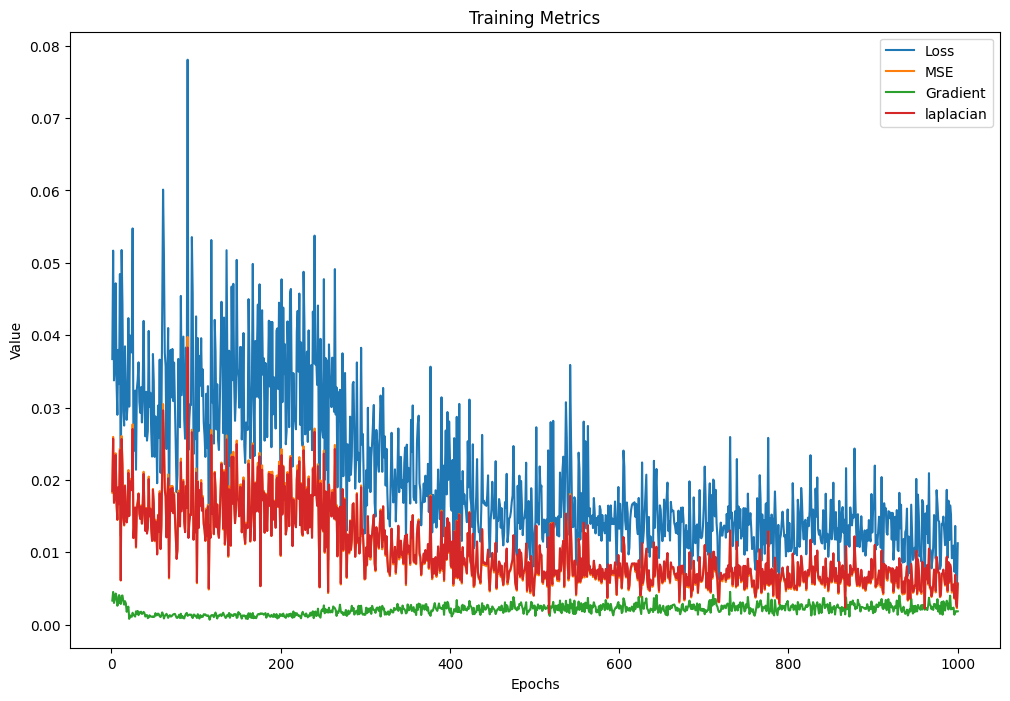

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 損失、MSE、勾配をプロット
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, total_loss_values, label='Loss')
plt.plot(epochs_range, mses, label='MSE')
plt.plot(epochs_range, grads, label='Gradient')
plt.plot(epochs_range, laplacian_losses, label='laplacian')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [17]:
model3D_4 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
model3D_4.to(device)
optimizer = optim.Adam(model3D_4.parameters(), lr=1e-4)

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[32, 64, 64]


In [18]:
from tqdm.notebook import tqdm

epochs = 500
losses = []
mses = []
grads = []

partial_weights = torch.load('model_VXM_3D_weights_laplacian_Loss_3_omomi.pth', map_location=device)
load_partial_state_dict(model3D_4, partial_weights)

for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images_64 = torch.nn.functional.interpolate(moving_images, size=(32, 64, 64), mode='trilinear', align_corners=False)
    fixed_images_64 = torch.nn.functional.interpolate(fixed_images, size=(32, 64, 64), mode='trilinear', align_corners=False)    
    moving_images_64 = moving_images_64.to(device)
    fixed_images_64 = fixed_images_64.to(device)

    moving_images_128 = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    fixed_images_128 = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)    
    moving_images_128 = moving_images_128.to(device)
    fixed_images_128 = fixed_images_128.to(device)

    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image_64, Vector_64 = model3D_3(moving_images_64, fixed_images_64)
    transformed_image_128, Vector_128 = model3D_4(moving_images_128, fixed_images_128)
    
    Vector_64_128 = torch.nn.functional.interpolate(Vector_64, size=(64, 128, 128), mode='trilinear', align_corners=False)
    Vector_64_128 = Vector_64_128*2
  
    loss = MSE_Loss(Vector_64_128, Vector_128)
    
    # 逆伝播
    loss.backward()
    optimizer.step()

    torch.save(model3D_4.state_dict(), 'model_VXM_3D_weights_laplacian_Loss_4_omomi.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

  0%|          | 0/500 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_7264\2423186746.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_7264\2423186746.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/500, Loss: 3.6006
Epoch 2/500, Loss: 23.9719
Epoch 3/500, Loss: 9.5223
Epoch 4/500, Loss: 69.8016
Epoch 5/500, Loss: 21.3374
Epoch 6/500, Loss: 10.2107
Epoch 7/500, Loss: 9.2828
Epoch 8/500, Loss: 20.2561
Epoch 9/500, Loss: 12.0266
Epoch 10/500, Loss: 12.3623
Epoch 11/500, Loss: 32.2413
Epoch 12/500, Loss: 10.6741
Epoch 13/500, Loss: 9.5286
Epoch 14/500, Loss: 10.6082
Epoch 15/500, Loss: 13.8902
Epoch 16/500, Loss: 52.9403
Epoch 17/500, Loss: 3.3229
Epoch 18/500, Loss: 4.7625
Epoch 19/500, Loss: 13.7763
Epoch 20/500, Loss: 9.3566
Epoch 21/500, Loss: 14.1998
Epoch 22/500, Loss: 12.6351
Epoch 23/500, Loss: 6.8268
Epoch 24/500, Loss: 7.6156
Epoch 25/500, Loss: 9.4094
Epoch 26/500, Loss: 9.0563
Epoch 27/500, Loss: 20.6753
Epoch 28/500, Loss: 5.7204
Epoch 29/500, Loss: 42.1298
Epoch 30/500, Loss: 17.0861
Epoch 31/500, Loss: 3.7406
Epoch 32/500, Loss: 5.8530
Epoch 33/500, Loss: 18.6929
Epoch 34/500, Loss: 8.1706
Epoch 35/500, Loss: 13.4500
Epoch 36/500, Loss: 4.4815
Epoch 37/500, Los

In [19]:
model3D_5 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
model3D_5.to(device)
optimizer = optim.Adam(model3D_5.parameters(), lr=1e-4)

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[32, 64, 64]


In [20]:
from tqdm.notebook import tqdm

epochs = E1
losses = []
mses = []
grads = []
laplacian_losses = []
total_loss_values = []

model3D_5.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_Loss_4_omomi.pth', map_location=device))

for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    
  # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, _ = model3D_5(moving_images, fixed_images)
    
    # 既存の損失を計算
    loss, mse, grad = total_loss(fixed_images, transformed_image)
    
    # Perceptual Lossを計算
    laplacian_loss = laplacian_pyramid_loss(transformed_image, fixed_images)
    
    # 最終的な損失を計算 (既存の損失とPerceptual Lossを足し合わせる)
    total_loss_value = loss + laplacian_loss
    
    # 逆伝播
    total_loss_value.backward()
    optimizer.step()

    torch.save(model3D_5.state_dict(), 'model_VXM_3D_weights_laplacian_Loss_5_omomi.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    mses.append(mse.cpu().item())
    grads.append(grad.cpu().item())
    laplacian_losses.append(laplacian_loss.cpu().item())    
    total_loss_values.append(total_loss_value.cpu().item())      

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss_value:.4f}, Mses: {mse}, Grad: {grad}, laplacian: {laplacian_loss}")

  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_7264\3133650230.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_7264\3133650230.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/1000, Loss: 0.0075, Mses: 0.0037152008153498173, Grad: 0.0013393433764576912, laplacian: 0.0038000652566552162
Epoch 2/1000, Loss: 0.0111, Mses: 0.005472500808537006, Grad: 0.0012968479422852397, laplacian: 0.005581673234701157
Epoch 3/1000, Loss: 0.0131, Mses: 0.0064999861642718315, Grad: 0.0014500938123092055, laplacian: 0.006588273216038942
Epoch 4/1000, Loss: 0.0125, Mses: 0.0062215798534452915, Grad: 0.0009332497138530016, laplacian: 0.006296597421169281
Epoch 5/1000, Loss: 0.0190, Mses: 0.009555807337164879, Grad: 0.0018866639584302902, laplacian: 0.009428469464182854
Epoch 6/1000, Loss: 0.0148, Mses: 0.007393536623567343, Grad: 0.0017695908900350332, laplacian: 0.007382324896752834
Epoch 7/1000, Loss: 0.0126, Mses: 0.006262567359954119, Grad: 0.0011664731428027153, laplacian: 0.0063045513816177845
Epoch 8/1000, Loss: 0.0146, Mses: 0.007252668496221304, Grad: 0.001448455499485135, laplacian: 0.0073521798476576805
Epoch 9/1000, Loss: 0.0117, Mses: 0.005783549509942532, Gra

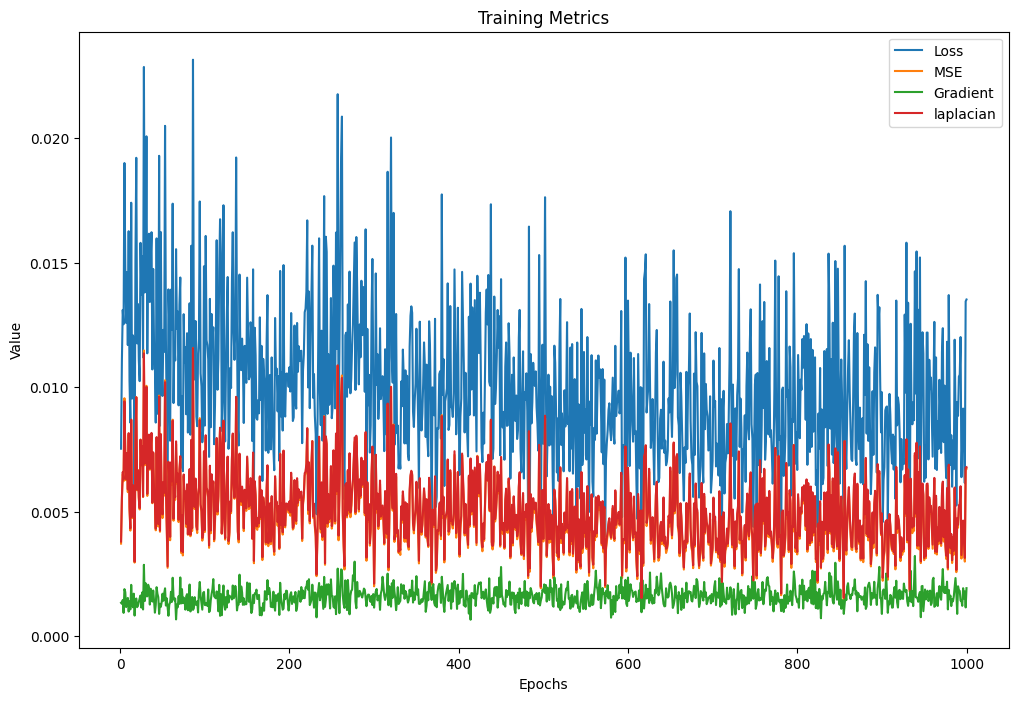

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 損失、MSE、勾配をプロット
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, total_loss_values, label='Loss')
plt.plot(epochs_range, mses, label='MSE')
plt.plot(epochs_range, grads, label='Gradient')
plt.plot(epochs_range, laplacian_losses, label='laplacian')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [22]:
model3D_6 = vxm.networks.VxmDense((128, 256, 256), nb_features, int_steps=0)
model3D_6.to(device)
optimizer = optim.Adam(model3D_6.parameters(), lr=1e-4)

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[64, 128, 128]


In [23]:
from tqdm.notebook import tqdm

epochs = 500
losses = []
mses = []
grads = []

partial_weights = torch.load('model_VXM_3D_weights_laplacian_Loss_5_omomi.pth', map_location=device)
load_partial_state_dict(model3D_6, partial_weights)

for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images_64 = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    fixed_images_64 = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)    
    moving_images_64 = moving_images_64.to(device)
    fixed_images_64 = fixed_images_64.to(device)
   
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image_64, Vector_64 = model3D_5(moving_images_64, fixed_images_64)
    transformed_image_128, Vector_128 = model3D_6(moving_images, fixed_images)
    
    Vector_64_128 = torch.nn.functional.interpolate(Vector_64, size=(128, 256, 256), mode='trilinear', align_corners=False)
    Vector_64_128 = Vector_64_128*2
  
    loss = MSE_Loss(Vector_64_128, Vector_128)
    
    # 逆伝播
    loss.backward()
    optimizer.step()

    torch.save(model3D_6.state_dict(), 'model_VXM_3D_weights_laplacian_Loss_6_omomi.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

  0%|          | 0/500 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_7264\3163476666.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_7264\3163476666.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/500, Loss: 266.5861
Epoch 2/500, Loss: 65.7607
Epoch 3/500, Loss: 26.2881
Epoch 4/500, Loss: 624.4247
Epoch 5/500, Loss: 126.3504
Epoch 6/500, Loss: 44.3923
Epoch 7/500, Loss: 126.4285
Epoch 8/500, Loss: 99.3429
Epoch 9/500, Loss: 140.7619
Epoch 10/500, Loss: 111.6512
Epoch 11/500, Loss: 113.8633
Epoch 12/500, Loss: 112.2016
Epoch 13/500, Loss: 97.1689
Epoch 14/500, Loss: 49.7239
Epoch 15/500, Loss: 218.9029
Epoch 16/500, Loss: 61.2320
Epoch 17/500, Loss: 12.8274
Epoch 18/500, Loss: 100.0128
Epoch 19/500, Loss: 122.6574
Epoch 20/500, Loss: 19.8761
Epoch 21/500, Loss: 30.5902
Epoch 22/500, Loss: 77.6608
Epoch 23/500, Loss: 25.3454
Epoch 24/500, Loss: 72.8329
Epoch 25/500, Loss: 56.1683
Epoch 26/500, Loss: 86.5371
Epoch 27/500, Loss: 68.1514
Epoch 28/500, Loss: 57.7310
Epoch 29/500, Loss: 241.3949
Epoch 30/500, Loss: 44.5340
Epoch 31/500, Loss: 99.0462
Epoch 32/500, Loss: 19.6204
Epoch 33/500, Loss: 68.9292
Epoch 34/500, Loss: 56.1634
Epoch 35/500, Loss: 13.3249
Epoch 36/500, Los

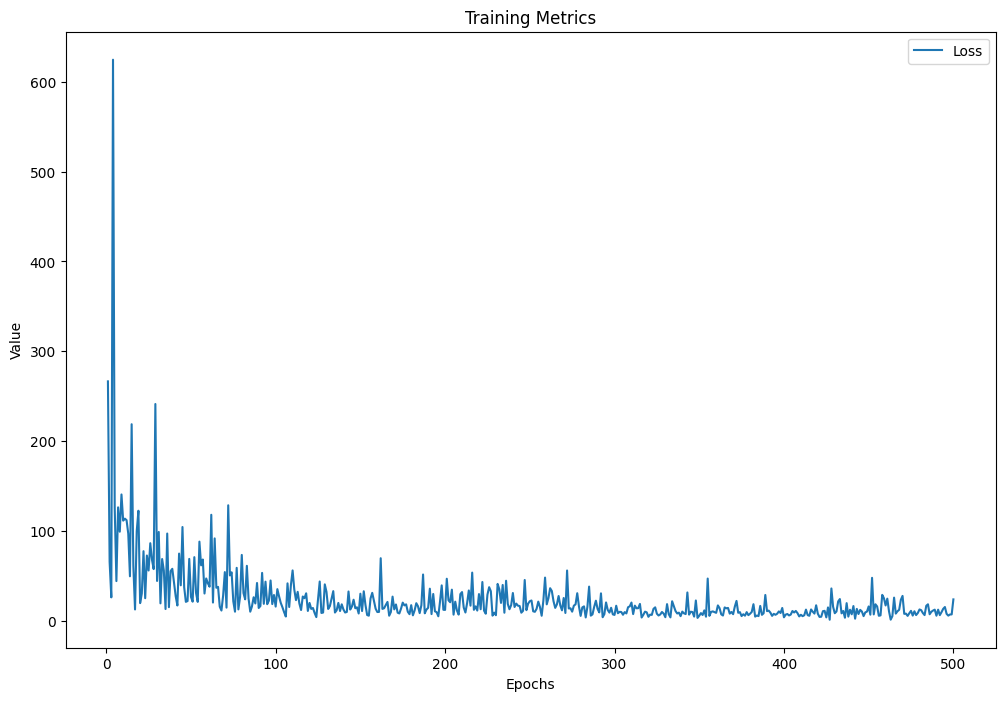

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 損失、MSE、勾配をプロット
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, losses, label='Loss')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [12]:
model3D_7 = vxm.networks.VxmDense((128, 256, 256), nb_features, int_steps=0)
model3D_7.to(device)
optimizer = optim.Adam(model3D_7.parameters(), lr=1e-4)

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[64, 128, 128]


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [26]:
from tqdm.notebook import tqdm

epochs = 500
losses = []
mses = []
grads = []
laplacian_losses = []
total_loss_values = []

partial_weights = torch.load('model_VXM_3D_weights_laplacian_Loss_6_omomi.pth', map_location=device)
load_partial_state_dict(model3D_7, partial_weights)

for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    
  # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, _ = model3D_7(moving_images, fixed_images)
    
    # 既存の損失を計算
    loss, mse, grad = total_loss(fixed_images, transformed_image)
    
    # Perceptual Lossを計算
    laplacian_loss = laplacian_pyramid_loss(transformed_image, fixed_images)
    
    # 最終的な損失を計算 (既存の損失とPerceptual Lossを足し合わせる)
    total_loss_value = loss + laplacian_loss
    
    # 逆伝播
    total_loss_value.backward()
    optimizer.step()

    torch.save(model3D_7.state_dict(), 'model_VXM_3D_weights_laplacian_Loss_7_omomi.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    mses.append(mse.cpu().item())
    grads.append(grad.cpu().item())
    laplacian_losses.append(laplacian_loss.cpu().item())    
    total_loss_values.append(total_loss_value.cpu().item())      

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss_value:.4f}, Mses: {mse}, Grad: {grad}, laplacian: {laplacian_loss}")

  0%|          | 0/500 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_7264\1729013019.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_7264\1729013019.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/500, Loss: 0.0187, Mses: 0.009341818280518055, Grad: 0.001526241539977491, laplacian: 0.009385956451296806
Epoch 2/500, Loss: 0.0054, Mses: 0.002665738109499216, Grad: 0.000910742674022913, laplacian: 0.0027742551174014807
Epoch 3/500, Loss: 0.0120, Mses: 0.005974723957479, Grad: 0.0009778530802577734, laplacian: 0.0060586389154195786
Epoch 4/500, Loss: 0.0129, Mses: 0.00640771072357893, Grad: 0.0013311603106558323, laplacian: 0.006524714175611734
Epoch 5/500, Loss: 0.0109, Mses: 0.005406348034739494, Grad: 0.0017679734155535698, laplacian: 0.005445678718388081
Epoch 6/500, Loss: 0.0143, Mses: 0.007130308076739311, Grad: 0.0008061101543717086, laplacian: 0.007203702814877033
Epoch 7/500, Loss: 0.0106, Mses: 0.005188962444663048, Grad: 0.0020737384911626577, laplacian: 0.005416793283075094
Epoch 8/500, Loss: 0.0120, Mses: 0.005976423621177673, Grad: 0.0014228681102395058, laplacian: 0.006032954901456833
Epoch 9/500, Loss: 0.0098, Mses: 0.004818607121706009, Grad: 0.0016508036060

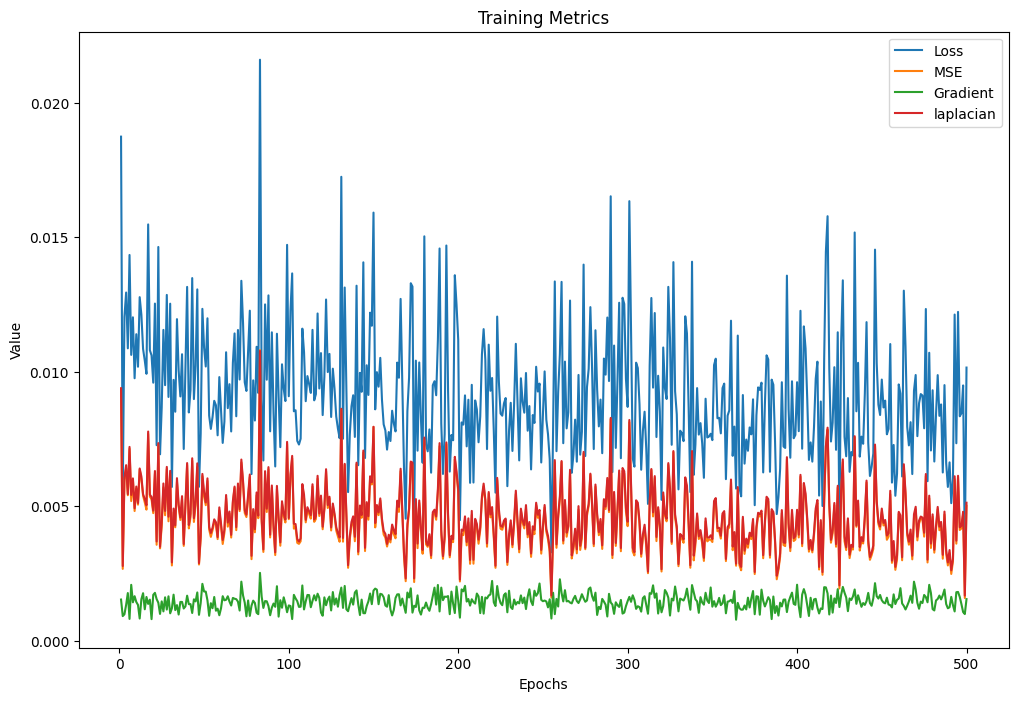

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 損失、MSE、勾配をプロット
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, total_loss_values, label='Loss')
plt.plot(epochs_range, mses, label='MSE')
plt.plot(epochs_range, grads, label='Gradient')
plt.plot(epochs_range, laplacian_losses, label='laplacian')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 学習済みモデルが既にある場合
model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_Loss_7_omomi.pth', map_location=device))
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_Adam1.pth', map_location=device))
CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D_7(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])


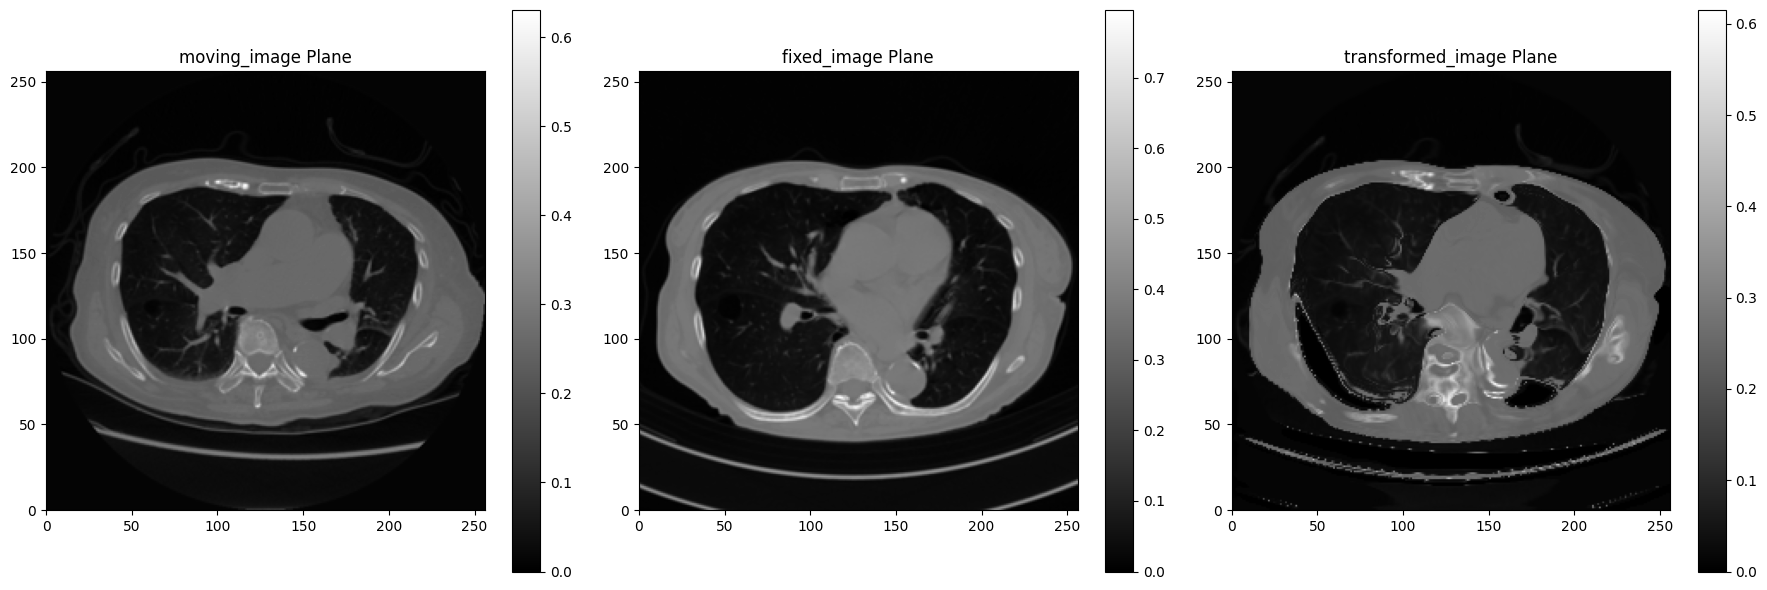

In [16]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 64

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [30]:
# imsave('moving_image.tiff', A)
# imsave('fixed_image.tiff', B)
# imsave('moved_image.tiff', C)

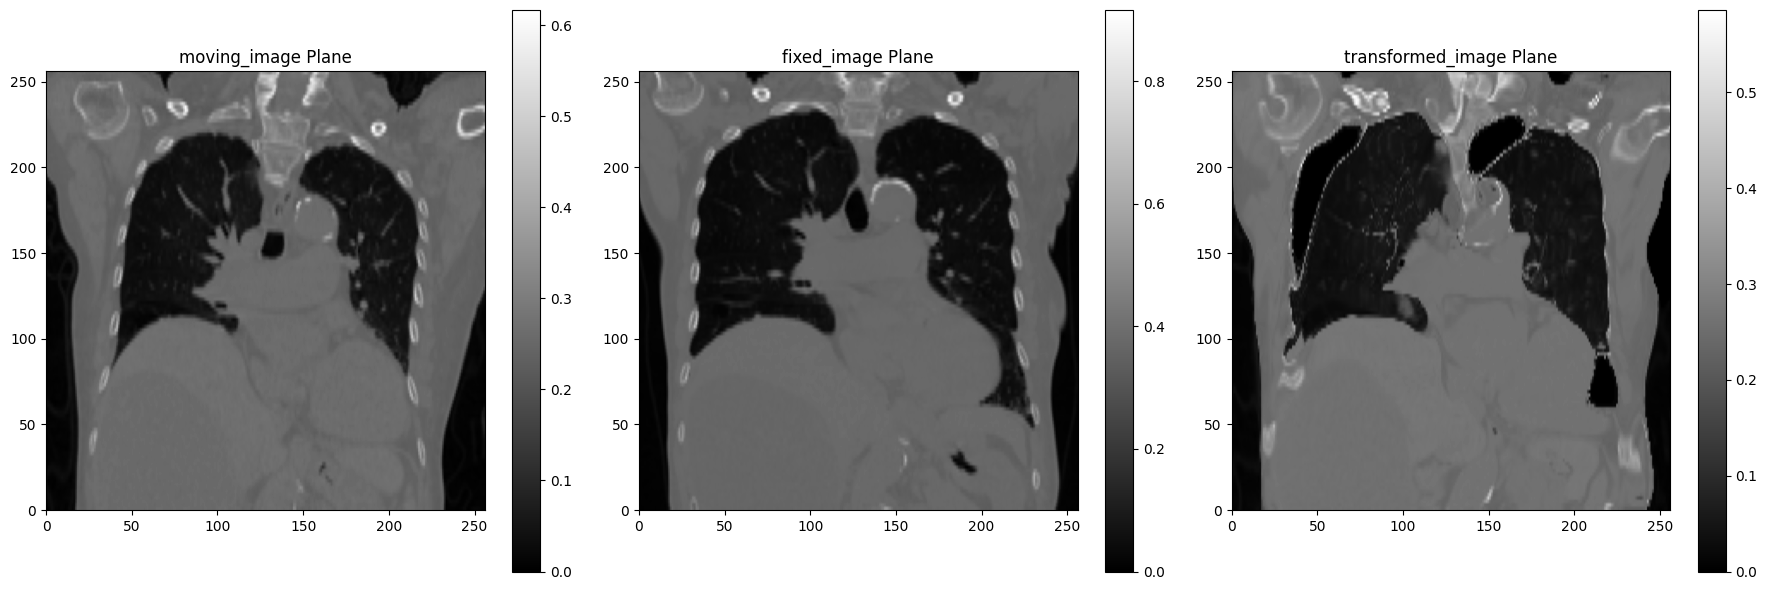

In [31]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 128

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, :, i, :]
plt.imshow(A, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, :, i, :]
plt.imshow(B, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, :, i, :]
plt.imshow(C, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

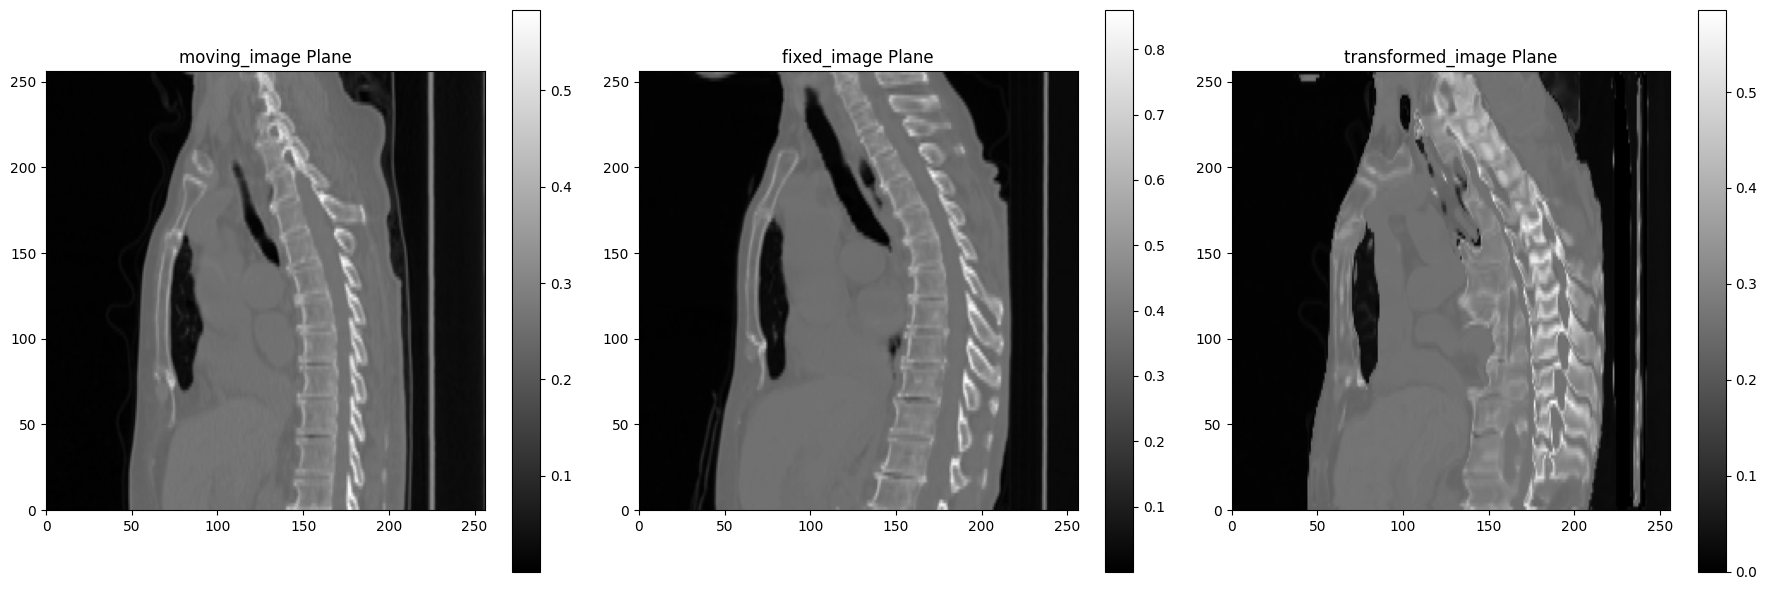

In [32]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 128

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, :, :, i]
plt.imshow(A, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, :, :, i]
plt.imshow(B, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, :, :, i]
plt.imshow(C, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])


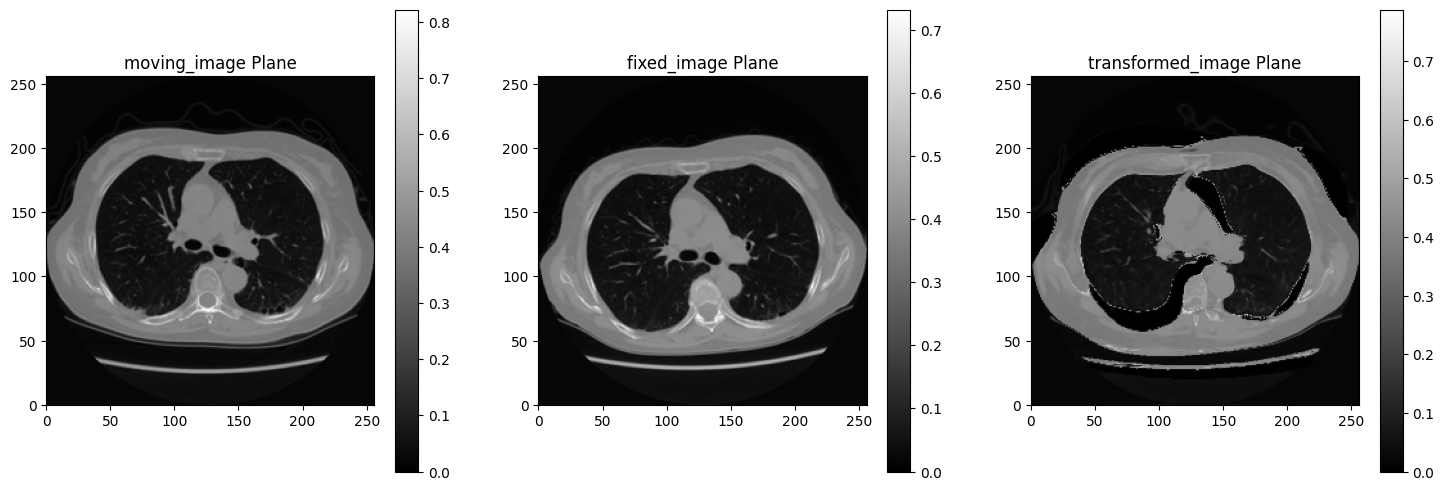

In [45]:
model3D_7.load_state_dict(torch.load('omomi.pth', map_location=device))

CT1 = np.load('No13_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No13_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D_7(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 50

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()

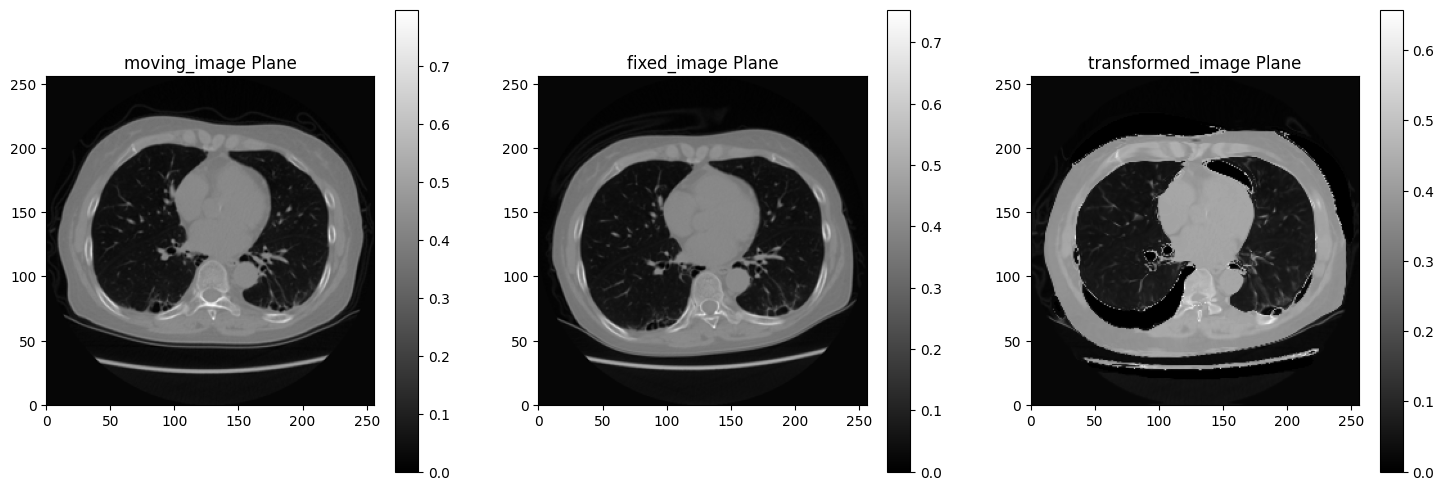

In [56]:
i = 70
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  #
# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()

In [57]:
# imsave('moving_image4.tiff', A)
# imsave('fixed_image4.tiff', B)
imsave('moved_image411.tiff', C)

C:\Users\user\AppData\Local\Temp\ipykernel_23080\3499825656.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_image411.tiff', C)


CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])


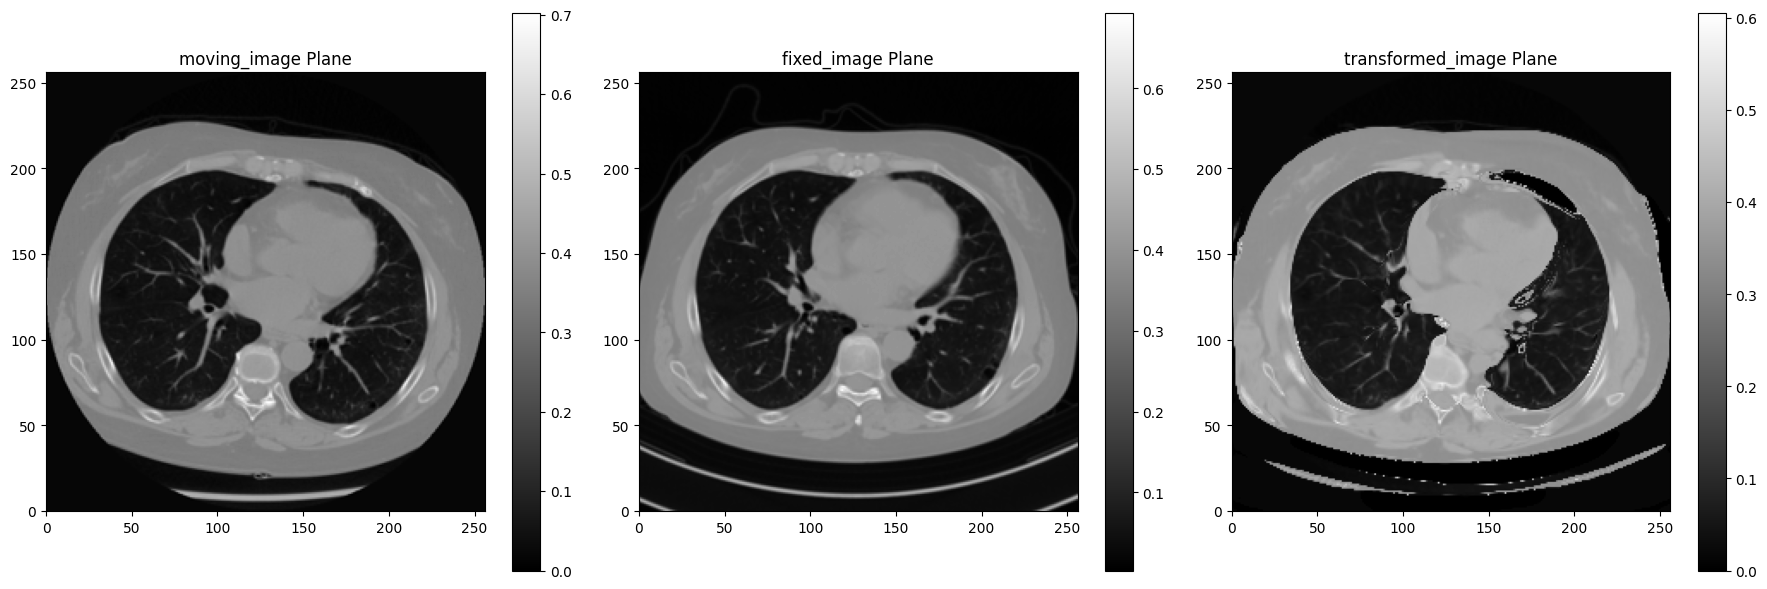

In [68]:
CT1 = np.load('No17_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No17_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D_7(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 66

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [59]:
# imsave('moving_image5.tiff', A)
# imsave('fixed_image5.tiff', B)
imsave('moved_image51.tiff', C)

C:\Users\user\AppData\Local\Temp\ipykernel_23080\1115593622.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_image51.tiff', C)


CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])


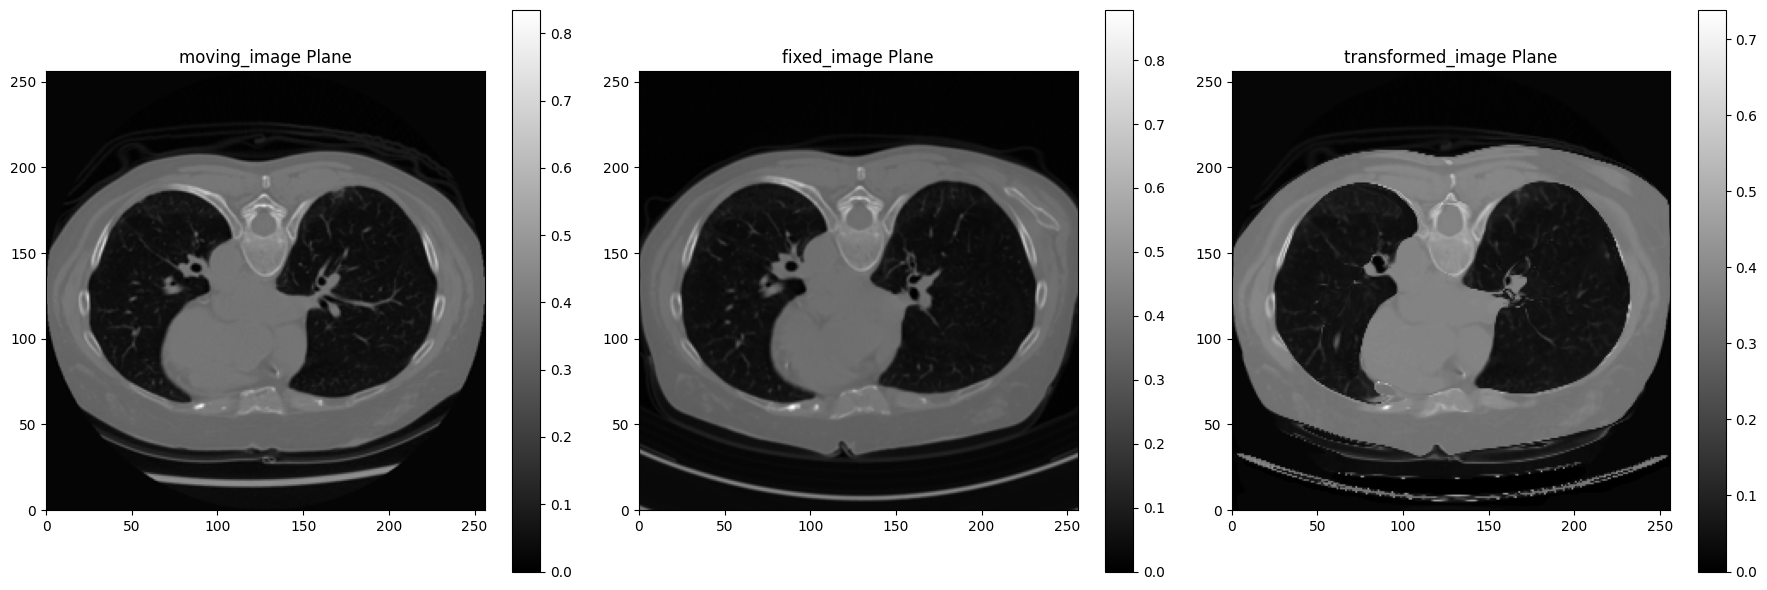

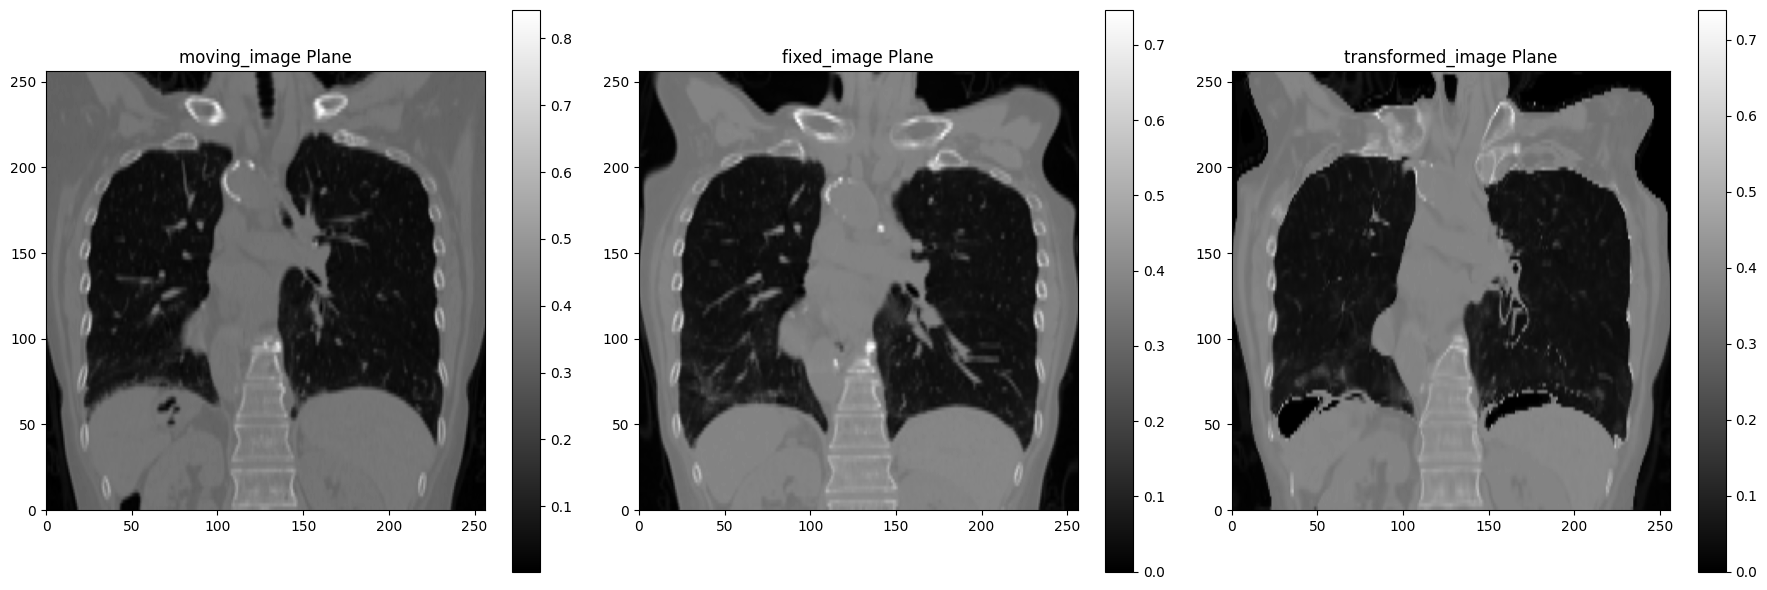

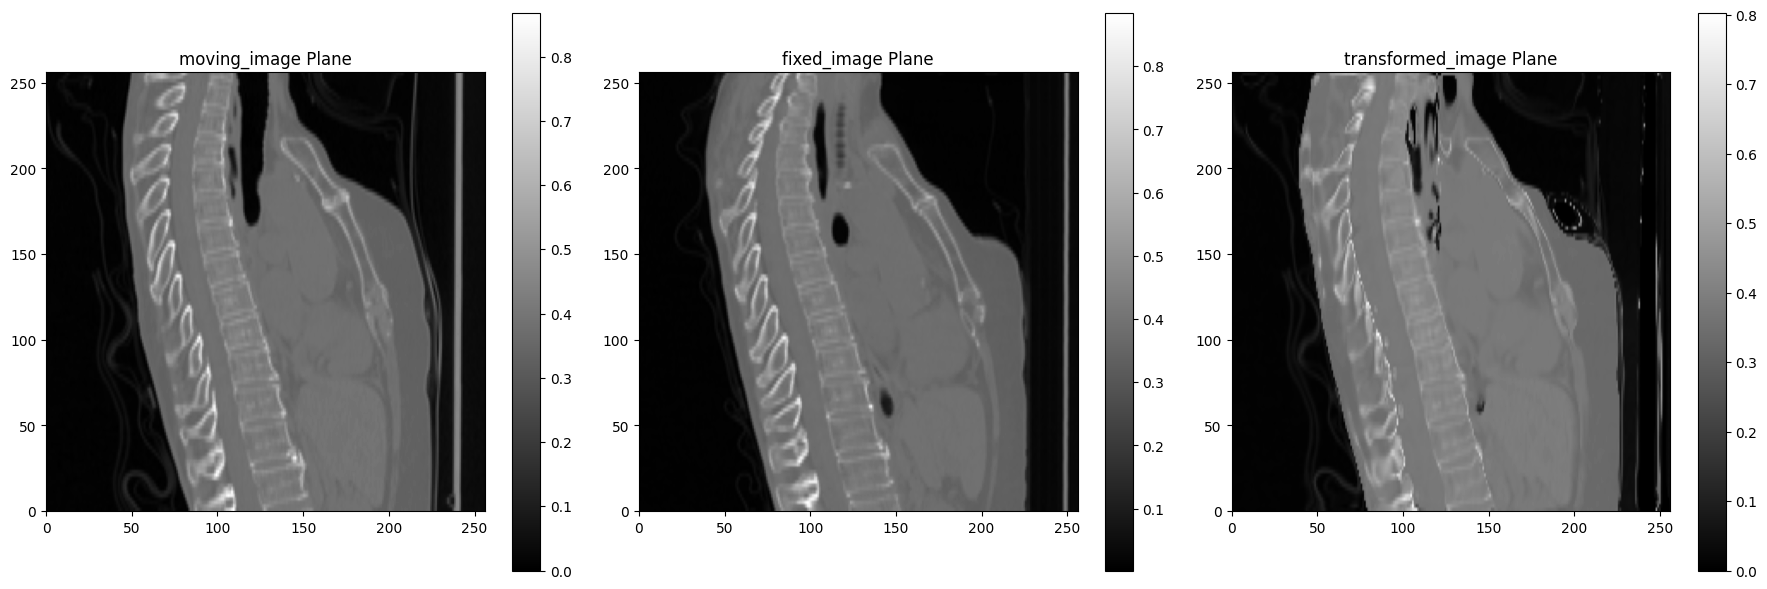

In [35]:
CT1 = np.load('No20_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No20_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D_7(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 64

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 128

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, :, i, :]
plt.imshow(A, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, :, i, :]
plt.imshow(B, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, :, i, :]
plt.imshow(C, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 128

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, :, :, i]
plt.imshow(A, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, :, :, i]
plt.imshow(B, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, :, :, i]
plt.imshow(C, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])


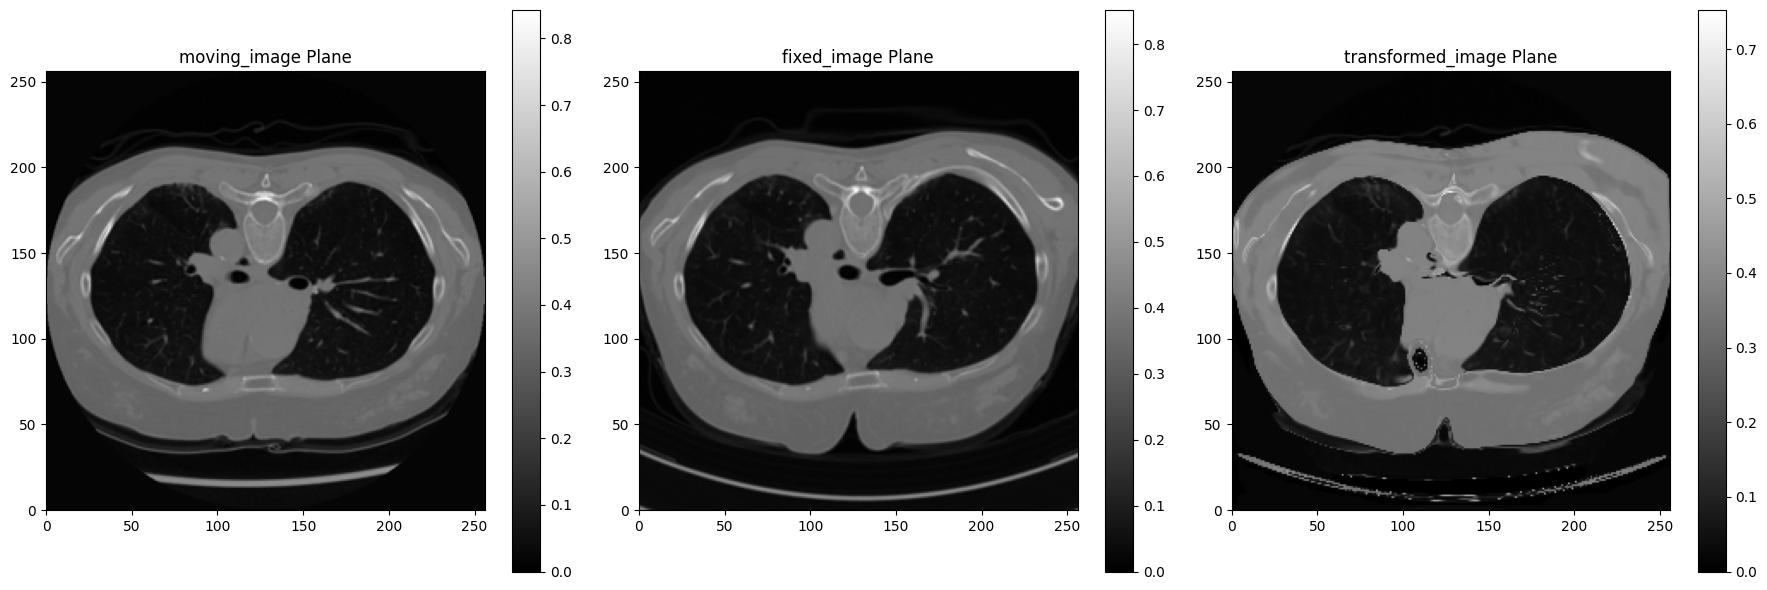

C:\Users\user\AppData\Local\Temp\ipykernel_23080\3003222439.py:80: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moving_image.tiff', A)
C:\Users\user\AppData\Local\Temp\ipykernel_23080\3003222439.py:81: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('fixed_image.tiff', B)
C:\Users\user\AppData\Local\Temp\ipykernel_23080\3003222439.py:82: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_image.tiff', C)


In [44]:
model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_Loss_7_omomi.pth', map_location=device))
# model3D_7.load_state_dict(torch.load('omomi.pth', map_location=device))

CT1 = np.load('No20_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No20_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D_7(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

import numpy as np
import torch
from tifffile import imsave
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 50

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 256, 0, 256])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()
imsave('moving_image.tiff', A)
imsave('fixed_image.tiff', B)
imsave('moved_image.tiff', C)

In [37]:
imsave('moving_image6.tiff', A)
imsave('fixed_image6.tiff', B)
imsave('moved_image61.tiff', C)

C:\Users\user\AppData\Local\Temp\ipykernel_23080\1681319186.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_image61.tiff', C)
